### Imports

In [1]:
from pprint import pprint
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, CenteredNorm
import numpy as np

from dolphin.processor.config import ModelConfig
from dolphin.processor import Processor
from dolphin.analysis.output import Output

In [2]:
processor = Processor("../io_directory_example/")

lens_name = "lens_system2"
model_id = "example"
reconstruction_id = "recon_v3"

In [3]:
# processor.swim(lens_name=lens_name, model_id=model_id, log=False)

In [4]:
output = Output("../io_directory_example/")
output.load_output(lens_name=lens_name, model_id=model_id)

grid_half_width = 1.  # arcsec, adjust as needed
pixel_size = 0.04  # arcsec
grid_pixels = int((grid_half_width * 2) / pixel_size)
source_grid_kwargs = {
    'pixel_width': pixel_size,
    'num_pixels_x': grid_pixels,
    'num_pixels_y': grid_pixels,
    'ra_at_xy_0': - (grid_pixels // 2 ) * pixel_size,
    'dec_at_xy_0': - (grid_pixels // 2 ) * pixel_size,
}
pprint(source_grid_kwargs)

{'dec_at_xy_0': -1.0,
 'num_pixels_x': 50,
 'num_pixels_y': 50,
 'pixel_width': 0.04,
 'ra_at_xy_0': -1.0}


In [5]:
regularization_kwargs = {
    'type': 'gradient',
    'lambda_bounds': [1e3, 1e7],
}

result = processor.reconstruct_source(
    lens_name=lens_name,
    model_id=model_id, 
    reconstruction_id=reconstruction_id,
    source_grid_kwargs=source_grid_kwargs,
    regularization_kwargs=regularization_kwargs,
    use_source_mask=True,              # Enable masking
    source_mask_type="snr",            # Use S/N-based mask
    source_mask_threshold=0.1,         # Mask pixels below some percentage of peak flux
    source_mask_sigma=2.0,             # Gaussian smoothing
)

Starting pixelated source reconstruction for lens_system2
Using lens model from: example
Source grid: 50 x 50 pixels
Pixel width: 0.0400 arcsec
Computing M matrix and b vector...
number of source pixels: 2500 (x axis: 50 pixels;  y axis: 50 pixels)
likelihood method: diagonal
Step 1: Lensing the source pixels
Step 1: Finished!
Step 2: Convolve the lensed pixels


Step 2: Finished!
Step 3: Compute the matrix M and vector b


Running (iteration times vary): 100%|██████████| 2500/2500 [02:44<00:00, 15.24it/s] 


Step 3: Finished!
Generating gradient regularization matrix...
Solving for optimal regularization strength...
Optimal λ: 1.00e+05
Solving for source pixel values...
  Used Cholesky decomposition (optimized for symmetric matrix)
Computing snr mask...
  Peak flux: 2.808e-02, threshold: 2.808e-03
  Effective source pixels: 1588.7/2500 (63.5%)
Generating model images...
  Rendering lens light component...
Source reconstruction complete!
Magnification: 7.132
Saving reconstruction output as: recon_v3


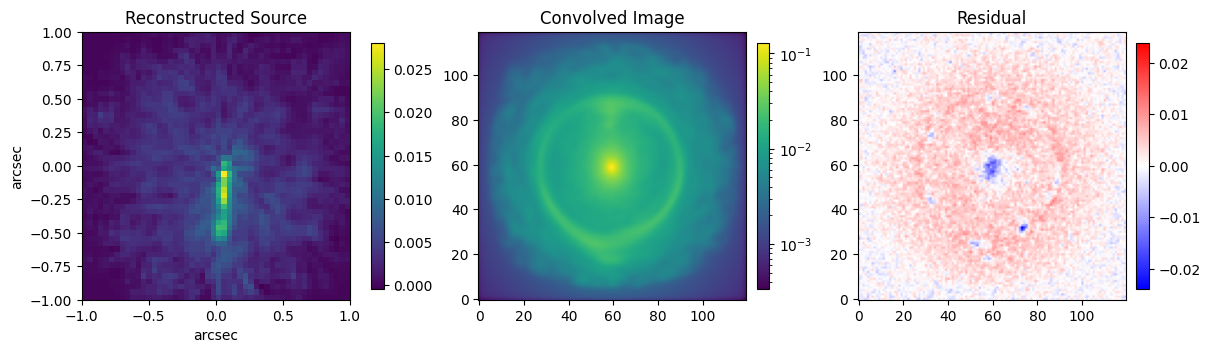

In [6]:
_, ax = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)

im0 = ax[0].imshow(result["source_image"], origin='lower', extent=[-grid_half_width, grid_half_width, -grid_half_width, grid_half_width])
ax[0].set_title("Reconstructed Source")
ax[0].set_xlabel("arcsec")
ax[0].set_ylabel("arcsec")
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(result["convolved_image"], origin='lower', norm=LogNorm())
ax[1].set_title("Convolved Image")
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

im2 = ax[2].imshow(result["residual"], origin='lower', norm=CenteredNorm(), cmap='bwr')
ax[2].set_title("Residual")
plt.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)

plt.savefig('pixelated_source_reconstruction.png', dpi=200)
plt.show()

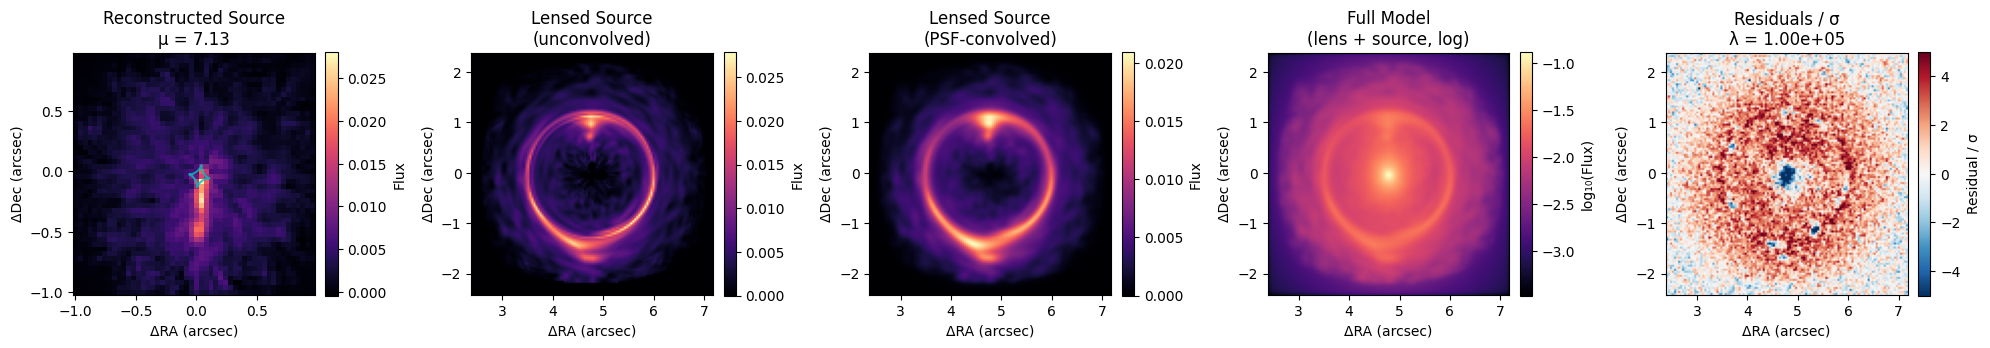

In [7]:
fig = output.plot_reconstruction_overview(
    lens_name=lens_name,
    reconstruction_id=reconstruction_id,
    band_index=0,
    show_caustics=True,  # Overlay caustics on source
    source_cmap="magma",  # Color scheme for source/model
    residual_cmap="RdBu_r",  # Color scheme for residuals
    figsize=(20, 4),
    v_max_residual=5
)
plt.savefig('reconstruction_overview.png', dpi=200)

-1.0664767524993726 reduced X^2 of all evaluated imaging data combined (without degrees of freedom subtracted).
reduced chi^2 of data  0 =  1.066476752499372


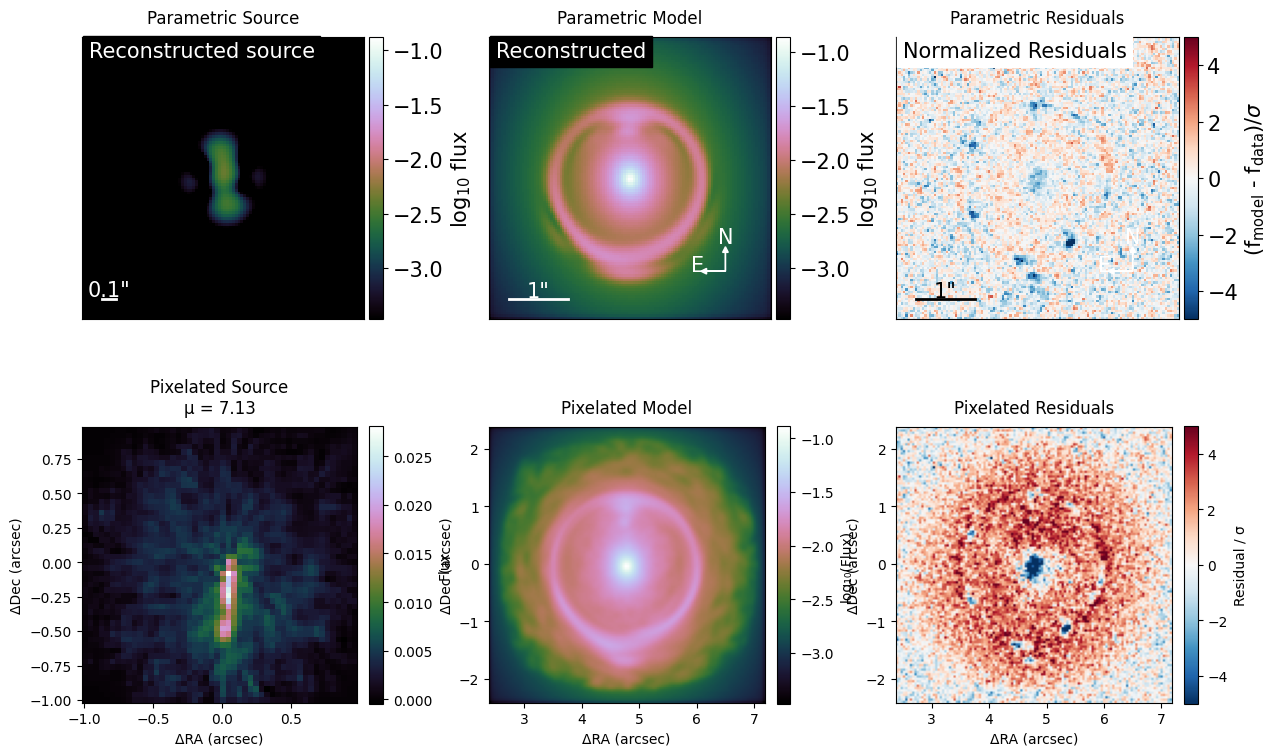

In [8]:
fig = output.plot_reconstruction_comparison(
    lens_name=lens_name,
    model_id=model_id,
    reconstruction_id=reconstruction_id,
    band_index=0,
    figsize=(12, 8)
)
plt.savefig('reconstruction_comparison.png', dpi=200)